In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

# Load monthly data
df = pd.read_csv('../data/tarkwa_nasa_monthly.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(df[['date', 'rainfall_mm']].head())

Dataset shape: (438, 11)
Date range: 1990-01-01 00:00:00 to 2026-06-01 00:00:00
        date  rainfall_mm
0 1990-01-01        36.92
1 1990-02-01        98.45
2 1990-03-01        70.49
3 1990-04-01       251.53
4 1990-05-01       187.32


In [2]:
# UNIVARIATE: use only the rainfall series
# Chronological 80/20 split
split_date = '2019-01-01'
train = df[df['date'] < split_date]['rainfall_mm'].values
test  = df[df['date'] >= split_date]['rainfall_mm'].values
train_dates = df[df['date'] < split_date]['date']
test_dates  = df[df['date'] >= split_date]['date']

print(f"Training months: {len(train)} (Jan 1990 – Dec 2018)")
print(f"Test months:     {len(test)}  (Jan 2019 – Jun 2026)")
print(f"Train mean: {train.mean():.1f} mm")
print(f"Test mean:  {test.mean():.1f} mm")

Training months: 348 (Jan 1990 – Dec 2018)
Test months:     90  (Jan 2019 – Jun 2026)
Train mean: 124.8 mm
Test mean:  181.3 mm


In [3]:
result = adfuller(train)
print("=== Augmented Dickey-Fuller Test (Training Set) ===")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Critical values:")
for key, val in result[4].items():
    print(f"   {key}: {val:.4f}")
print(f"\nConclusion: Series is {'NOT ' if result[1] > 0.05 else ''}stationary at 5% significance level")

=== Augmented Dickey-Fuller Test (Training Set) ===
ADF Statistic : -3.6874
p-value       : 0.0043
Critical values:
   1%: -3.4500
   5%: -2.8702
   10%: -2.5714

Conclusion: Series is stationary at 5% significance level


In [4]:
print("Running auto_arima to find best SARIMA order...")
print("This may take a few minutes...\n")

auto_model = auto_arima(
    train,
    seasonal=True,
    m=12,                    # monthly seasonality
    d=None,                  # let auto_arima determine differencing
    D=None,                  # let auto_arima determine seasonal differencing
    stepwise=True,
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    max_d=2, max_D=1,
)

print(f"\nBest order:         {auto_model.order}")
print(f"Best seasonal order:{auto_model.seasonal_order}")
print(f"AIC: {auto_model.aic():.2f}")

Running auto_arima to find best SARIMA order...
This may take a few minutes...

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.45 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=4060.366, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=3843.220, Time=0.37 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=3909.094, Time=0.30 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=4474.329, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=3993.676, Time=0.01 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=3778.346, Time=1.01 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=3827.430, Time=1.68 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=3732.985, Time=0.73 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=3918.235, Time=0.29 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=3756.333, Time=1.55 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=3869.878, Time=0.85 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.24 sec
 ARIMA(0,0,0)(1,

In [5]:
p, d, q = auto_model.order
P, D, Q, m = auto_model.seasonal_order

print(f"Fitting SARIMA({p},{d},{q})({P},{D},{Q})[{m}] on full training set...")

sarima_model = SARIMAX(
    train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, m),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

Fitting SARIMA(1,0,0)(1,0,1)[12] on full training set...
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  348
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 12)   Log Likelihood               -1777.674
Date:                              Tue, 21 Jul 2026   AIC                           3563.348
Time:                                      17:28:35   BIC                           3578.605
Sample:                                           0   HQIC                          3569.430
                                              - 348                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1883      0.051      3.7

In [6]:
# Walk-forward (rolling) forecast — refit model each step
# using all data up to that point for maximum accuracy
print("Running walk-forward validation on test set...")

history = list(train)
predictions = []

for i in range(len(test)):
    model = SARIMAX(
        history,
        order=(p, d, q),
        seasonal_order=(P, D, Q, m),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    yhat = fit.forecast(steps=1)[0]
    yhat = max(0, yhat)   # rainfall cannot be negative
    predictions.append(yhat)
    history.append(test[i])
    if (i+1) % 10 == 0:
        print(f"  Completed {i+1}/{len(test)} steps")

predictions = np.array(predictions)
print("Walk-forward validation complete.")

Running walk-forward validation on test set...
  Completed 10/90 steps
  Completed 20/90 steps


c:\Users\USER\Desktop\droplet_ai\droplet_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Completed 30/90 steps
  Completed 40/90 steps
  Completed 50/90 steps
  Completed 60/90 steps
  Completed 70/90 steps
  Completed 80/90 steps
  Completed 90/90 steps
Walk-forward validation complete.


In [7]:
mae  = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
r2   = r2_score(test, predictions)

# MAPE over non-zero months only
mask = test > 0
mape = np.mean(np.abs((test[mask] - predictions[mask]) / test[mask])) * 100

print("=== SARIMA (Univariate) — Test Set Performance ===")
print(f"MAE  : {mae:.2f} mm")
print(f"RMSE : {rmse:.2f} mm")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%  (non-zero months only)")

=== SARIMA (Univariate) — Test Set Performance ===
MAE  : 52.58 mm
RMSE : 71.92 mm
R²   : 0.6291
MAPE : 42.89%  (non-zero months only)


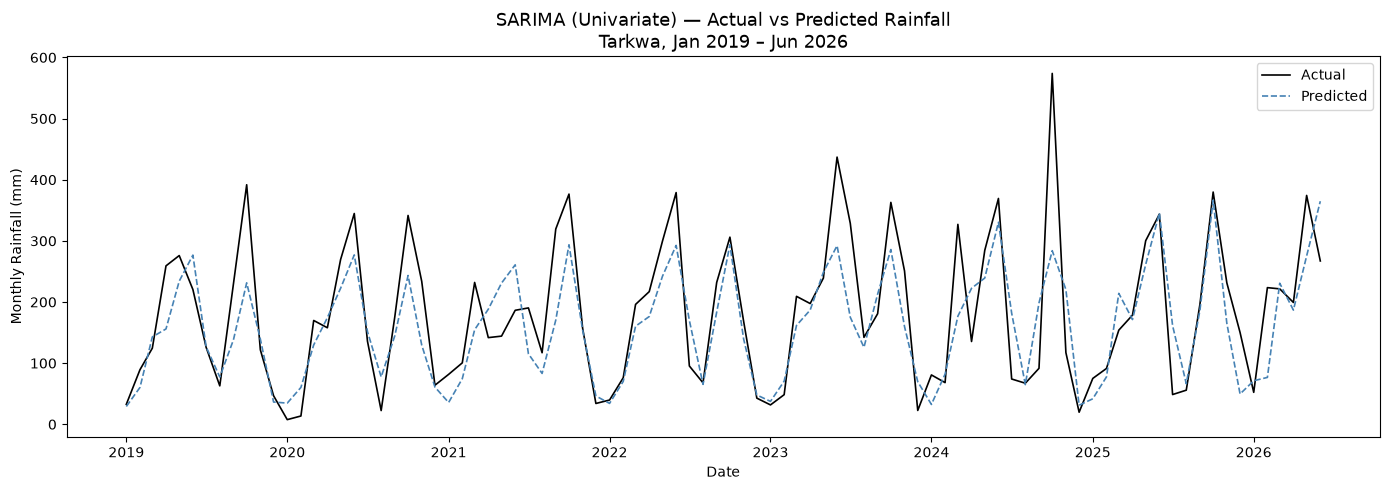

Plot saved.


In [8]:
plt.figure(figsize=(14, 5))
plt.plot(test_dates.values, test,        label='Actual',    color='black', linewidth=1.2)
plt.plot(test_dates.values, predictions, label='Predicted', color='steelblue',
         linewidth=1.2, linestyle='--')
plt.title('SARIMA (Univariate) — Actual vs Predicted Rainfall\nTarkwa, Jan 2019 – Jun 2026',
          fontsize=13)
plt.xlabel('Date')
plt.ylabel('Monthly Rainfall (mm)')
plt.legend()
plt.tight_layout()
os.makedirs('../models', exist_ok=True)
plt.savefig('../models/sarima_uni_actual_vs_predicted.png', dpi=150)
plt.show()
print("Plot saved.")

In [9]:
# Save the final fitted SARIMA model (fitted on full training set)
joblib.dump({
    'model_fit': sarima_fit,
    'order': (p, d, q),
    'seasonal_order': (P, D, Q, m),
    'train_data': train,
    'model_type': 'SARIMA_univariate',
}, '../models/sarima_uni_model.pkl')

# Save metrics for comparison table
results = {
    'model': 'SARIMA',
    'mode': 'univariate',
    'mae': round(mae, 2),
    'rmse': round(rmse, 2),
    'r2': round(r2, 4),
    'mape': round(mape, 2),
    'order': f"({p},{d},{q})({P},{D},{Q})[{m}]",
}
import json
with open('../models/sarima_uni_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Model saved to models/sarima_uni_model.pkl")
print("Results saved to models/sarima_uni_results.json")
print(f"\nSummary: SARIMA{results['order']}")
print(f"  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  MAPE={mape:.2f}%")

Model saved to models/sarima_uni_model.pkl
Results saved to models/sarima_uni_results.json

Summary: SARIMA(1,0,0)(1,0,1)[12]
  MAE=52.58  RMSE=71.92  R²=0.6291  MAPE=42.89%
